In [ ]:
%pip install -U --quiet langchain tiktoken langchain_openai langchain-community


# Understanding the Agentic AI Reflection Pattern

In the evolving landscape of artificial intelligence, **Agentic AI** represents a significant shift towards systems capable of autonomous decision-making and self-improvement. Central to this paradigm is the **Reflection Pattern**, a design approach that enables AI models, especially large language models (LLMs), to iteratively generate, evaluate, and refine their outputs.

## What is the Reflection Pattern?

The Reflection Pattern is an iterative process where an AI model:

1. **Generates** an initial response to a given prompt.
2. **Reflects** on this output to assess its quality and accuracy.
3. **Refines** the response based on the self-assessment, repeating the cycle until the output meets predefined standards.

This approach mirrors human cognitive processes, where individuals draft, review, and revise their work to achieve clarity and precision.

## Steps Involved in the Reflection Pattern

1. **Generation Step**: The AI produces an initial response to the user's prompt.
2. **Reflection Step**: The system evaluates its own output, identifying areas for improvement.
3. **Iteration and Refinement**: Based on the reflection, the AI revises its response, repeating the process to enhance quality.

This cyclical process continues until the output aligns with desired quality metrics or meets specific stopping criteria.

## Why Use the Reflection Pattern?

Implementing the Reflection Pattern offers several benefits:

- **Enhanced Accuracy**: By critically assessing its own outputs, the AI can identify and correct errors, leading to more precise responses.
- **Improved Quality**: Iterative refinement allows the AI to produce content that is clearer and more coherent.
- **Autonomous Learning**: The self-assessment loop enables the AI to learn from its outputs, gradually improving performance without human intervention.

## Practical Applications

The Reflection Pattern is particularly effective in scenarios requiring high-quality content generation, such as:

- **Text Generation**: Creating articles, reports, or creative writing pieces that require multiple drafts and revisions.
- **Code Development**: Writing and refining code snippets, ensuring functionality and optimization.
- **Complex Problem Solving**: Addressing intricate tasks that benefit from step-by-step refinement and evaluation.

By adopting the Reflection Pattern, AI systems can emulate human-like iterative processes, leading to more reliable and sophisticated outputs.


# Challenges and Limitations of Reflection Agents Prompting

1. **Computational Overhead**: Processing of complex systems could be increased by reflection.
2. **Architecture Complexity**: Adding reflection to existing systems may increase complexity, either in terms of providing more robust feedback or memory structures.
3. **Scalability**: Complexity in tasks increases with each cycle of reflection and may be difficult to remain efficient.
4. **Over-Reflection**: The agents may get locked in over-reflection loops which would delay the decisions.
5. **Feedback Bias**: Inappropriate criteria of reflection would lead the agents to provide biased or partial feedback that would result in inferior outcomes.


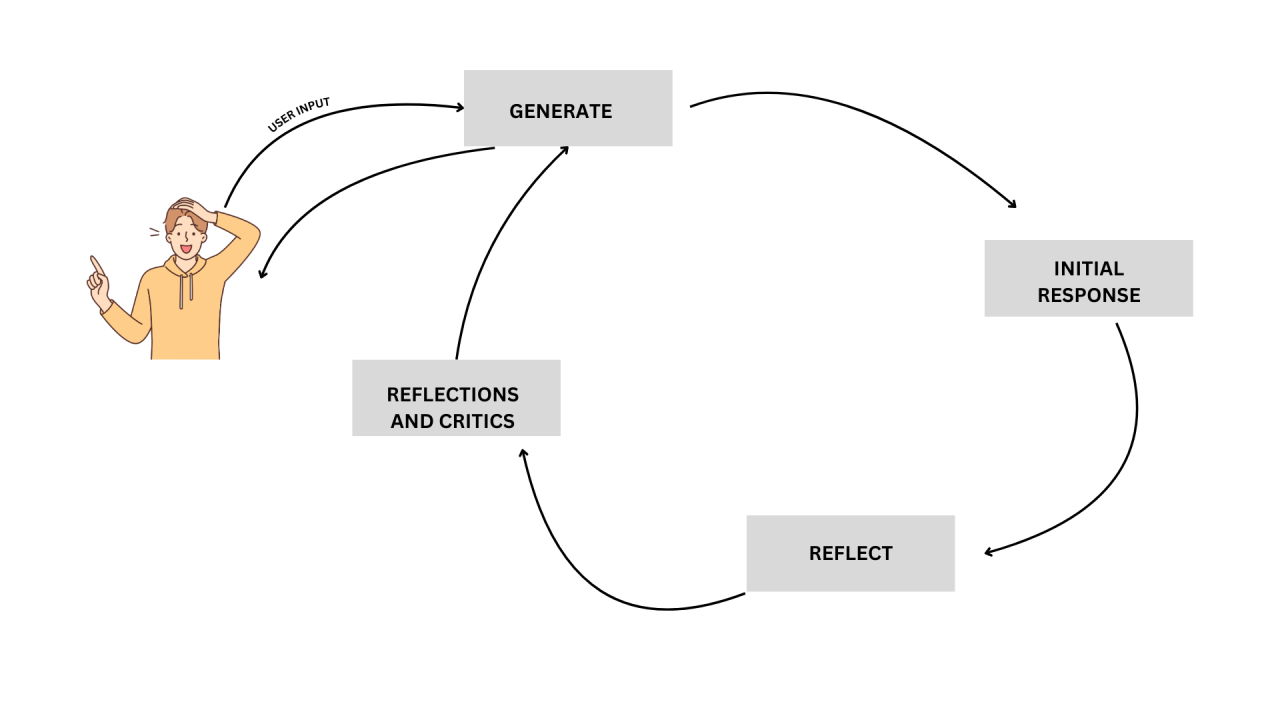

In [ ]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get('openai_api_key')

In [ ]:

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import (StrOutputParser)

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder


In [ ]:
data = [
    {
        "text": """شرکت جهان فولاد سیرجان از تغییر اعضای هیات مدیره خبر داد.
کد خبر : ۲۷۷۸۸۵
به گزارش بورس نیوز، شرکت جهان فولاد سیرجان از تغییر اعضای هیات مدیره خبر داد.

بر اساس این گزارش، باستناد مصوبۀ مجمع عمومی عادی مورخ ۱۴۰۱/۰۲/۱۰ و جلسۀ هیئت مدیرۀ مورخ ۱۴۰۲/۱۰/۰۳ اسامی اعضای هیئت مدیره و نمایندگان آن‌ها تغییر یافته است.""",
        "stock": "فجهان"
    },
    {
        "text": """به گزارش بورس نیوز، آمار معاملات بازار فیزیکی بورس کالای ایران نشان می‌دهد در هفته منتهی به ۲۹ دی ۴۰۷ شرکت در تالار‌ها و بازار فرعی کالا و محصولشان را عرضه کردند که به معامله ۳ میلیون و ۸۹۷ هزار تن انواع کالا و محصول به ارزش ۳۱.۲ هزار میلیارد تومان منتهی شد. ارزش معاملات ۱۰ شرکت برتر ۱۲.۹ هزار میلیارد تومان برآورد شد.

به گزارش کالاخبر، بورس کالای ایران برترین‌های بورس کالا در هفته منتهی به ۲۹ دی را براساس ارزش فروش شرکت‌ها در بازار فیزیکی اعلام کرد.

جزییات رتبه‌بندی جایگاه شرکت‌ها از لحاظ فروش به شرح زیر است:

فولاد خوزستان "فخوز" با ثبت معامله ۱۰۵ هزار و ۶۰ تن شمش بلوم، تختال و آرگون به ارزش ۲ هزار و ۱۹۴ میلیارد تومان در رتبه نخست ایستاد""",
        "stock": "فخوز"
    },
    {
        "text": """میزان درآمد ماهانه خکاوه در آذرماه نسبت به میانگین درآمدی در ۸ ماه گذشته ۵۹ درصد پایین‌تر بود.""",
        "stock": "خکاوه"
    },
    {
        "text": """به گزارش بورس نیوز، بانک اقتصاد نوین از عدم حصول نتیجه از برگزاری مزایده خبر داد.

بر اساس این گزارش، این بانک اعلام کرد، مزایده تعداد ۳۹۹.۹۸۰.۰۰۰ سهم معادل ۴۰ درصد از سهام شرکت کارگزاری بانک اقتصاد نوین را از طریق مزایده به صورت نقد و اقساط برگزار و با عدم ارائه پیشنهاد از طرف اشخاص حقیقی و حقوقی مواجه شد.""",
        "stock": "ونوین"
    },
    {
        "text": """به گزارش بورس نیوز، شرکت توسعه سامانه‌های نرم افزاری نگین از برگزاری مجمع عمومی عادی سالیانه خبر داد.

بر این اساس، این شرکت اعلام کرد، از کلیه سهامداران، وکیل یا قائم مقام قانونی صاحب سهم و همچنین نماینده یا نمایندگان اشخاص حقوقی دعوت می شود تا در جلسه مجمع عمومی این شرکت که در ساعت ۰۹:۳۰ روز یکشنبه مورخ ۱۴۰۳/۰۱/۱۹ در استان تهران، شهر تهران به آدرس خیابان ولیعصر - نرسیده به پل پارک وی - حد فاصل خیابان تورج و خیابان خاکزاد - مجموعه فرهنگی و ورزشی تلاش حضور بهم رسانند.

لازم به ذکر است، در این جلسه درباره استماع گزارش هیئت مدیره و بازرس قانونی، تصویب صورت‌های مالی سال (دوره) مالی منتهی به ۱۴۰۲/۰۹/۳۰، انتخاب حسابرس و بازرس قانونی، انتخاب روزنامة کثیر‌الانتشار، انتخاب اعضای هیئت‌مدیره، تعیین حق حضور اعضای غیر موظف هیئت مدیره، تعیین پاداش هیئت مدیره تصمیم گیری می‌شود.""",
        "stock": "نگین"
    },
    {
        "text": """بر این اساس، این شرکت اعلام کرد، بر اساس تصمیمات مجمع عمومی فوق العاده افزایش سرمایۀ شرکت از مبلغ ۱,۳۸۵,۴۹۴ میلیون ریال به‌مبلغ ۱۳,۳۱۳,۲۱۱ میلیون ریال از محل مازاد تجدید ارزیابی دارایی‌ها مبلغ ۱۱۹۲۷۷۱۷ میلیون ریال در تاریخ ۱۴۰۲/۱۲/۲۸ در مرجع ثبت شرکت‌ها به ثبت رسیده است.""",
        "stock": "پاک"
    },
    {
        "text": """زیان خالص "کساپا" در پایان شهریورماه سال جاری برابر با یک میلیارد و ۳۳۸ میلیون تومان به اطلاع سهامداران رسید.
کد خبر : ۲۶۳۴۲۲
زیان خالص ۵۸ ریالی سایپا شیشه در ازای هر سهم+بورس نیوز

بورس نیوز:

شرکت سایپا شیشه در گزارش صورت‌های مالی میاندوره‌ای تلفیقی ۶ ماهه منتهی به شهریورماه ۱۴۰۱ مجموع درآمد عملیاتی خود طی این دوره ۶ ماهه را برابر با ۱۸۲ میلیارد تومان به اطلاع سهامداران رساند، میزان درآمدی که در پایان نیمه نخست سال جاری به ثبت رسید افزایش ۸۵ درصدی را نسبت به دوره مشابه سال گذشته به همراه داشت.

بهای تمام‌شده درآمد عملیاتی "کساپا" در انتهای شهریورماه برابر با ۱۷۴ میلیارد تومان بود که نسبت به درآمد عملیاتی به‌دست‌آمده در این دوره ۹۵ درصد از میزان درآمد را در برگرفته است و بر همین اساس که حجم عمده‌ای از آن صرف بهای تمام‌شده درآمد‌های عملیاتی شد و در نهایت به سود ناخالص ۸ میلیارد و ۲۳۷ میلیون تومانی رسید.

زیان خالص ۵۸ ریالی سایپا شیشه در ازای هر سهم+بورس نیوز

میزان سود ناخالص در مقایسه با دوره مشابه سال گذشته ۱۳ درصد کاهش یافت، به‌گونه‌ای که از مبلغ ۹ میلیارد ۴۴۰ میلیون تومان سود ناخالص به مبلغ ۸ میلیارد و ۲۳۷ میلیون تومان رسید، هزینه‌های مالی سایپا شیشه در پایان شهریورماه ۳۴۸ میلیون تومان شناسایی شد.

شرکت سایپا شیشه در پایان دوره ۶ ماهه میاندوره‌ای منتهی به شهریورماه ۱۴۰۰ مجموع سود عملیاتی  خود را برابر با ۳ میلیارد و ۷۶۶ میلیون به ثبت رساند، در پایان نیمه نخست سال جاری "کساپا" به زیان عملیاتی ۴۸۷ میلیون تومانی رسید.

زیان خالص ۵۸ ریالی سایپا شیشه در ازای هر سهم+بورس نیوز

زیان خالص "کساپا" در پایان شهریورماه سال جاری برابر با یک میلیارد و ۳۳۸ میلیون تومان به اطلاع سهامداران رسید، این بخش در دوره مشابه سال گذشته با سود یک هزار و ۴۸۳ میلیون تومان همراه بود، "کساپا" در ازای هر سهم نیز طی این دوره ۵۸ ریال زیان شناسایی کرد.

صورت‌وضعیت مالی منتهی به پایان شهریورماه ۱۴۰۱
"kساپا" در گزارش صورت‌وضعیت مالی میاندوره‌ای ۶ ماهه خود مجموع دارایی‌های ثبت‌شده را نزدیک به ۱۷۰ میلیارد تومان ارائه کرد، این شرکت شاهد رشد ۶۸ درصدی دارایی‌های خود نسبت به پایان سال مالی گذشته بود، بیشترین دارایی در اختیار بخش «دریافتنی‌های تجاری و سایر دریافتنی‌ها» با ۸۶ میلیارد تومان بود.

بخش دریافتنی‌های تجاری و سایر دریافتنی‌ها نسبت به پایان سال گذشته ۳۵ درصد رشد را به همراه داشت و پس‌ازآن نیز «موجودی مواد و کالا» با ۳۸ میلیارد تومان در بخش دارایی‌های جاری قرار گرفت که افزایش ۶۳ درصدی را نسبت به پایان سال مالی گذشته به ثبت رساند.

زیان خالص ۵۸ ریالی سایپا شیشه در ازای هر سهم+بورس نیوز

طی این دوره ۶ میاندوره‌ای منتهی به شهریورماه ۱۴۰۱ میزان سرمایه "کساپا" مبلغی بالغ‌بر ۲۳ میلیارد تومان اعلام شد که در مقایسه با پایان سال گذشته بدون تغییر باقی ماند و همچنین این شرکت در این دوره ۶ ماهه به زیان انباشته یک میلیارد و ۴۶۹ میلیون تومانی رسید، این در صورتی است که در پایان سال مالی گذشته زیان انباشته این شرکت ۱۳۱ میلیون تومان بود و اکنون با افزایش ۱۰۱۷ درصدی روبه‌رو است.

زیان خالص ۵۸ ریالی سایپا شیشه در ازای هر سهم+بورس نیوز

همان‌طور که گفته شد مجموع درآمد‌های عملیاتی شرکت "کساپا" در پایان دوره ۶ ماهه میاندوره‌ای منتهی به شهریورماه سال ۱۴۰۱ برابر با ۱۸۲ میلیارد تومان شناسایی‌شده، درآمد‌های این شرکت از فروش محصولات در بازار داخل کشور به دست آمد.

بیشترین درآمدی در دوره ۶ ماهه ابتدایی سال مالی به دست آمد از بخش «انواع شیشه ایمنی تیبا» بود که برای شرکت ۱۲۰ میلیارد تومان درآمدزایی را به همراه داشت و پس از آن نیز «انواع شیشه ایمنی پراید» برابر با ۳۲ میلیارد تومان بود.

پایان مطلب""",
        "stock": "کساپا"
    },
    {
        "text": """بخوانیم از عملکرد شرکت صنعتی زر ماکارون در اسفندماه؛
"غزر" با رشد ۲۸ درصدی به استقبال سال جدید رفت

کد خبر : ۲۷۹۵۸۴
بورس نیوز:

شرکت صنعتی زر ماکارون با سرمایه ثبت شده ۲ هزار و ۴۵۰ میلیارد تومانی و ارزش بازار ۵ هزار و ۹۴۰ میلیارد تومانی در آخرین گزارش عملکر ماهانه منتهی به اسفند ماه، از تحقق درآمد ۶۱۱ میلیارد تومانی خود خبر داده است.

"غزر"  با رشد ۱۲ درصدی نسبت به بهمن‌ماه به رکود درآمد گذشته خود  در این ماه؛ دوباره دست یافته و پایانی خوش در سال ۱۴۰۲ را رقم زده است.
درآمد تجمیعی این شرکت در ۱۲ ماهه منتهی به اسفند ۱۴۰۲ برابر با ۵ هزار و ۹۶۰ میلیارد تومان بوده است که این میزان نسبت به دوره مشابه سال گذشته رشدی ۲۸ درصدی را به ثمر رسانده است.

از اصلی‌ترین رشد‌های " غزر"، فروش صادراتی این شرکت بوده است که با ثبت رقم ۸۴ میلیارد تومانی رشدی عالی نسبت به ۶ ماهه دوره ذکر شده کسب کرده است.

سبد محصولات شرکت صنعتی زر ماکارون از محصولات متنوعی برخودار بوده که در این بین پرفروش محصولات آن «ماکارونی رشته‌ای» با سهم ۵۳ درصدی، بیش از ۳۲۴ میلیارد تومان درآمد کسب کرده است.

مابقی درآمد‌هایی که زر ماکارون از فروش دیگر محصولات خود شناسایی کرده برابر با ۲۸۲ میلیارد تومان بوده است. گفتنی است محصولات صادراتی "غزر" در ۳ حوزه «محصولات فرمی، خاص، رشته‌ای» در اسفندماه حدود ۸۴ میلیارد و ۶۰۰ میلیون تومان درآمدزایی به همراه داشته است.
پایان مطلب""",
        "stock": "غزر"
    },
    {
        "text": """صنايع ريخته گري ايران ثبت کرد؛
ثبت افزایش سرمایه "خریخت" از محل تجدید ارزیابی ها
ثبت افزایش سرمایه
شرکت صنايع ريخته گري ايران از ثبت افزایش سرمایه خبر داد.
کد خبر : ۲۷۹۵۷۶
به گزارش بورس نیوز، شرکت صنايع ريخته گري ايران از ثبت افزایش سرمایه خبر داد.

با عنایت به مجوز افزایش سرمایه بر اساس تصمیمات مجمع عمومی فوق العاده مورخ ۱۴۰۲/۱۲/۱۹ افزایش سرمایۀ شرکت از مبلغ ۳,۰۰۰,۰۰۰ میلیون ریال به‌مبلغ ۱۰,۸۰۹,۲۴۹ میلیون ریال (از محل مازاد تجدید ارزیابی دارایی‌ها مبلغ ۷۸۰۹۲۴۹ میلیون ریال در تاریخ ۱۴۰۳/۰۱/۱۴ در مرجع ثبت شرکت‌ها به ثبت رسیده است.""",
        "stock": "صنايع ريخته گري ايران"
    },
    {
        "text": """بانک صادرات ایران با ۱۲۰ همت سرمایه به بزرگترین بانک بورسی تبدیل می‌شود
بانک صادرات ایران با ۱۲۰ همت سرمایه به بزرگترین بانک بورسی تبدیل می‌شود
​معاون مالی بانک صادرات ایران از افزایش سرمایه ۴۵۷ درصدی بانک صادرات ایران تا ۱۲۰۰ هزار میلیارد ریال و کسب جایگاه اول این بانک در بین بانک‌های بازار سرمایه خبر داد.
کد خبر : ۲۷۹۴۳۳
به گزارش بورس نیوز، سید مجتبی صالحی، ​معاون مالی بانک صادرات ایران اظهار کرد: با نهایی شدن مراحل بعدی افزایش سرمایه بانک صادرات ایران از محل تجدید ارزیابی دارایی‌ها، مجموع سرمایه ثبتی بانک به ۱۲۰۰ هزار میلیارد ریال  خواهد رسید و رتبه اول بانک‌های حاضر در بازار سرمایه را کسب خواهد کرد.

وی تاکید کرد: مرحله اول افزایش سرمایه بانک صادرات ایران در ۲۵ آذرماه سال جاری به صورت سلب حق تقدم و آورده نقدی به مبلغ ۴۰ هزار میلیارد ریالی به میزان حدود ۲۳ درصد در مجمع عمومی فوق‌العاده بانک مورد تصویب قرار گرفت و سرمایه قبلی ۱۷۵ میلیون و ۳۵۳ هزار و ۹۷۲ میلیون ریالی بانک صادرات ایران به ۲۱۵ میلیون و ۳۵۳ هزار و ۹۷۲ میلیون ریال رسید.

دبیر کمیسیون مالی شورای هماهنگی بانک‌ها اظهار کرد: مراحل بعدی افزایش سرمایه بانک طبق وعده مدیران بانک عملیاتی شده و با نهایی شدن مراحل افزایش سرمایه از محل تجدید ارزیابی دارایی‌ها، سرمایه بانک به ۱۲۰۰ هزار میلیارد ریال خواهد رسید که جایگاه اول در بین بانک‌های بازار سرمایه را به خود اختصاص خواهد داد.

اصلاح ساختار مالی و توجه به استاندارد‌های بین‌المللی حسابداری از جمله حسابداری مصون‌سازی در مسیر بانک توسعه‌ای و حضور مؤثرتر در اقتصاد کشور و منطقه از جمله اهداف بلند مدت در نقشه راه این بانک است و افزایش سرمایه و همچنین تحول در بانکداری نوین زمینه‌س|از تحقق این اهداف به شمار می‌آید.""",
        "stock": "بانک صادرات ایران"
    },
    {
        "text": """وزیر اقتصاد گفت: انتشار گواهی اوراق سپرده خاص با سود ۳۰ درصد در ستاد اقتصادی دولت مطرح و تصمیم گرفته شده بود که انتشار محدود این اوراق برای پروژه‌های ویژه در دستور کار قرار بگیرد.
کد خبر : ۲۷۸۸۷۳
به گزارش بورس نیوز، احسان خاندوزی، وزیر اقتصاد اظهار کرد: انتشار گواهی اوراق سپرده خاص با سود ۳۰ درصد در ستاد اقتصادی دولت مطرح و تصمیم گرفته شده بود که انتشار محدود این اوراق برای پروژه‌های ویژه در دستور کار قرار بگیرد.

وی افزود: بانک مرکزی هم همان موضوعی که در ستاد اقتصادی دولت تصمیم گرفته شده بود را اجرایی کرد و شایعاتی که در مورد اختلافات وجود دارد، علاقه‌های برخی افراد است که دنبال اختلاف آفرینی هستند و به این موضوع دامن می‌زنند.

وزیر اقتصاد در مورد اینکه آیا بانکی با مدیریت سرپرست اداره می‌شود، گفت: در بین بانک‌های تحت مدیریت دولت، فقط بانک ملت است که در واقع مدیرعامل آن پیشنهاد شده و در مرحله مصاحبه‌ها در بانک مرکزی است که به‌زودی منصوب می‌شود و بانک دیگر با مدیریت سرپرست نداریم.""",
        "stock": "بانک ملت"
    },
    {
        "text": """به گزارش بورس نیوز، این تفاهم‌نامه که در جریان برگزاری پنجمین نمایشگاه خودرو تهران و با حضور وزیر صمت به امضا رسید، گروه صنعتی ایران‌خودرو به همراه شرکت مپنا و چهار خودروساز دیگر شامل سایپا، مدیران‌خودرو، گروه بهمن و کرمان موتور برای ایجاد و توسعه شبکه سرویس‌دهی مشتریان شارژ خودروی برقی و خدمات مربوط مشارکت می‌کند.

موضوع این تفاهم‌نامه ایجاد زمینه مشارکت و همکاری در انجام مطالعات جامع درخصوص نصب، راه‌اندازی و بهره‌برداری از ایستگاه‌های شارژ و گسترش شبکه خدمات رسانی بر خط و حضوری مشتریان محصولات برقی است.

ایران‌خودرو به عنوان نخستین خودروساز داخلی کشور که به طراحی و تولید خودرو برقی اقدام کرده، در زمینه ایجاد امکان بهره‌برداری از خودرو‌های برقی توسط مشتریان و ارایه خدمات پس از فروش گسترده نیز پیشگام بوده و آماده مشارکت در زمینه ایجاد ایستگاه‌های شارژ خودروهاست.""",
        "stock": "ایران‌خودرو"
    },
    {
        "text": """به گزارش بورس نیوز،  در متن پیام وی آمده است:

پیروزی انقلاب اسلامی مرهون خون شهیدانی است که دلاورانه در مقابل ستم پیشگان ایستادند و با نثار خونشان درخت انقلاب را آبیاری کردند و امروز ایران اسلامی به برکت خون آن‌ها و رادمردی‌های مردان و زنان در تلاش و مؤمن، طی بیش از چهار دهه، شاهد شکوفایی در تمامی عرصه‌های مختلف اقتصادی، اجتماعی، فرهنگی و هنری بر پایه آموزه‌های اسلامی است و مسیر موفقیت کشور با رهبری مقام معظم رهبری همچنان افق‌های تازه‌ای را در سطح جهانی طی می‌کند.

۱۲ بهمن یادآور خاطره بازگشت بنیانگذار و معمار فرزانه انقلاب اسلامی امام خمینی (ره) به ایران، همه ساله آغاز دهه مبارک فجر و روز‌های به ثمر رسیدن انقلاب اسلامی است.

من فرارسیدن این روز و یوم‌الله دهه مبارک فجر را به عموم مردم ایران، کارکنان نظام بانکی به ویژه همکاران بانک صادرات ایران تبریک عرض می‌کنم. بانک صادرات ایران در مسیر پایمردی برای حفظ ارزش‌های انقلاب و کمک به تحقق اهداف اقتصادی در کنار مردم و مسئولان دلسوز کشور ایستاده و همچون همیشه از تمامی ظرفیت‌های خود استفاده خواهد کرد.""",
        "stock": "صادرات ایران"
    },
    {
        "text": """به گزارش بورس نیوز، ​محسن سیفی، مدیرعامل بانک صادرات ایران با صدور پیامی درگذشت دکتر رضا دولت‌آبادی، مدیرعامل بانک ملت و از چهره‌های ماندگار نظام بانکی را تسلیت گفت.

در پیام محسن سیفی آمده است:

«کل من علی‌ها فان و یبقی وجه ربک ذوالجلال و الاکرام»

درگذشت مدیرعامل فقید بانک ملت و چهره ماندگار و تأثیرگذار شبکه بانکی کشور، جناب آقای رضا دولت‌آبادی، موجب اندوه و تأسف قلبی همه مدیران و کارکنان شبکه بانکی کشور شد.

این چهره برجسته نظام بانکی کشور با صداقت، مسئولیت‌پذیری، اهتمام و همدلی، منشأ خیرات و برکات فراوان در اقتصاد کشور شد و نام نیک او در خاطر همه ما جاودانه خواهد ماند.

اینجانب ضمن تسلیت به خانواده گرامی ایشان، کارکنان محترم شبکه بانکی و همکاران معظم بانک ملت، از درگاه خداوند متعال، برای روح آن مرحوم مغفرت الهی و برای اعضای خانواده، بازماندگان، دوستان و همکاران ایشان صبر و شکیبایی مسئلت دارم.

محسن سیفی_ ​مدیرعامل بانک صادرات ایران""",
'stock' :"بانک ملت"
    }]

In [ ]:
system_message = """
You are a financial analyst. Please read the following news article and say how it might affect the stock price.
Choose one of these three options:
1. Positive (meaning the price will likely go up)
2. Neutral (meaning no significant change is expected)
3. Negative (meaning the price will likely go down)

News Article: '{text}'
Stock: {stock}
Your Analysis:
- your classification goes here:"""

In [ ]:
prompt = ChatPromptTemplate.from_messages([
    ("system", system_message),
])


In [ ]:
chain = prompt | llm | StrOutputParser()

In [ ]:
# prompt = ChatPromptTemplate.from_messages([
#     ("system", """Perform a sentiment analysis on the provided news. If the user provides feedback, respond only with a revised version of your initial attempt, nothing else."""),
#     MessagesPlaceholder(variable_name="messages")
# ])

In [ ]:
i = -2
print(data[i]['text'])
print(data[i]['stock'])
print(chain.invoke(data[i]))

به گزارش بورس نیوز،  در متن پیام وی آمده است:

پیروزی انقلاب اسلامی مرهون خون شهیدانی است که دلاورانه در مقابل ستم پیشگان ایستادند و با نثار خونشان درخت انقلاب را آبیاری کردند و امروز ایران اسلامی به برکت خون آن‌ها و رادمردی‌های مردان و زنان در تلاش و مؤمن، طی بیش از چهار دهه، شاهد شکوفایی در تمامی عرصه‌های مختلف اقتصادی، اجتماعی، فرهنگی و هنری بر پایه آموزه‌های اسلامی است و مسیر موفقیت کشور با رهبری مقام معظم رهبری همچنان افق‌های تازه‌ای را در سطح جهانی طی می‌کند.

۱۲ بهمن یادآور خاطره بازگشت بنیانگذار و معمار فرزانه انقلاب اسلامی امام خمینی (ره) به ایران، همه ساله آغاز دهه مبارک فجر و روز‌های به ثمر رسیدن انقلاب اسلامی است.

من فرارسیدن این روز و یوم‌الله دهه مبارک فجر را به عموم مردم ایران، کارکنان نظام بانکی به ویژه همکاران بانک صادرات ایران تبریک عرض می‌کنم. بانک صادرات ایران در مسیر پایمردی برای حفظ ارزش‌های انقلاب و کمک به تحقق اهداف اقتصادی در کنار مردم و مسئولان دلسوز کشور ایستاده و همچون همیشه از تمامی ظرفیت‌های خود استفاده خواهد کرد.
صادرات ایران
Based on the content of the 

In [ ]:
def generation(llm, system_message):
  prompt = ChatPromptTemplate.from_messages(
    [("system",system_message), MessagesPlaceholder(variable_name="messages")])
  generate = prompt | llm | StrOutputParser()
  return generate

In [ ]:
# human_message_order = HumanMessage(content=f"""
# solely Focuse on the sentiment reflected only by the terms related to the influence of the news on the rising or declining price of the {stock}
#   while disregarding any other irrelevant information, such as historical events, social aspects, or unrelated congratulatory or condolences messages.
#   Please 'ONLY' output 'one' sentiment from [Positive / Neutral / Negative ]. news:{text}, stock:{stock}""")
# messages = [human_message_order]

In [ ]:
data[i]

{'text': 'به گزارش بورس نیوز،  در متن پیام وی آمده است:\n\nپیروزی انقلاب اسلامی مرهون خون شهیدانی است که دلاورانه در مقابل ستم پیشگان ایستادند و با نثار خونشان درخت انقلاب را آبیاری کردند و امروز ایران اسلامی به برکت خون آن\u200cها و رادمردی\u200cهای مردان و زنان در تلاش و مؤمن، طی بیش از چهار دهه، شاهد شکوفایی در تمامی عرصه\u200cهای مختلف اقتصادی، اجتماعی، فرهنگی و هنری بر پایه آموزه\u200cهای اسلامی است و مسیر موفقیت کشور با رهبری مقام معظم رهبری همچنان افق\u200cهای تازه\u200cای را در سطح جهانی طی می\u200cکند.\n\n۱۲ بهمن یادآور خاطره بازگشت بنیانگذار و معمار فرزانه انقلاب اسلامی امام خمینی (ره) به ایران، همه ساله آغاز دهه مبارک فجر و روز\u200cهای به ثمر رسیدن انقلاب اسلامی است.\n\nمن فرارسیدن این روز و یوم\u200cالله دهه مبارک فجر را به عموم مردم ایران، کارکنان نظام بانکی به ویژه همکاران بانک صادرات ایران تبریک عرض می\u200cکنم. بانک صادرات ایران در مسیر پایمردی برای حفظ ارزش\u200cهای انقلاب و کمک به تحقق اهداف اقتصادی در کنار مردم و مسئولان دلسوز کشور ایستاده و همچون همیشه از تمامی ظرف

In [ ]:
gen_chain = generation(llm, system_message)
messages = []
i = -1
input_dict = data[i]
input_dict.update({'messages':messages})

gen_chain.invoke(input_dict, )

'3. Negative (meaning the price will likely go down) \n\nThe passing of a prominent figure like Dr. Reza Dowlati, the CEO of Bank Mellat, may lead to uncertainty and concern among investors about the stability and future direction of the bank. The news may negatively impact investor sentiment, potentially causing the stock price to decline as stakeholders react to the loss of a key leader in the banking sector.'

In [ ]:
input_dict

{'text': 'به گزارش بورس نیوز، \u200bمحسن سیفی، مدیرعامل بانک صادرات ایران با صدور پیامی درگذشت دکتر رضا دولت\u200cآبادی، مدیرعامل بانک ملت و از چهره\u200cهای ماندگار نظام بانکی را تسلیت گفت.\n\nدر پیام محسن سیفی آمده است:\n\n«کل من علی\u200cها فان و یبقی وجه ربک ذوالجلال و الاکرام»\n\nدرگذشت مدیرعامل فقید بانک ملت و چهره ماندگار و تأثیرگذار شبکه بانکی کشور، جناب آقای رضا دولت\u200cآبادی، موجب اندوه و تأسف قلبی همه مدیران و کارکنان شبکه بانکی کشور شد.\n\nاین چهره برجسته نظام بانکی کشور با صداقت، مسئولیت\u200cپذیری، اهتمام و همدلی، منشأ خیرات و برکات فراوان در اقتصاد کشور شد و نام نیک او در خاطر همه ما جاودانه خواهد ماند.\n\nاینجانب ضمن تسلیت به خانواده گرامی ایشان، کارکنان محترم شبکه بانکی و همکاران معظم بانک ملت، از درگاه خداوند متعال، برای روح آن مرحوم مغفرت الهی و برای اعضای خانواده، بازماندگان، دوستان و همکاران ایشان صبر و شکیبایی مسئلت دارم.\n\nمحسن سیفی_ \u200bمدیرعامل بانک صادرات ایران',
 'stock': 'بانک ملت',
 'messages': []}

In [ ]:
# from typing import Optional
# from pydantic import BaseModel, Field
# class SentimentAnalyser(BaseModel):
#     '''Identifying information about news sentiment.'''

#     sentiment: str = Field(..., description="the sentiment of news, only can be one of [neutral, positive, negative]")

In [ ]:
def do_reflection(llm):
  reflection_prompt = ChatPromptTemplate.from_messages(
      [("system","""Your task is to review the sentiment analysis results for the news article about {stock}.
  1. Assess whether the sentiment (Positive, Neutral, or Negative) accurately reflects the impact of the news on the stock's price movement.

  News: '{text}'
  Stock: '{stock}',
"""),MessagesPlaceholder(variable_name="messages"),])


  reflect = reflection_prompt | llm | StrOutputParser()
  return reflect

In [ ]:
max_attempt = 5
reflection_chain = do_reflection(llm)
generation_chain = generation(llm, system_message)

ii = -1
input_dict = data[ii]
messages = []
input_dict.update({'messages':messages})
cls_map = {"ai": HumanMessage, "human": AIMessage}

counter = 0
while counter < max_attempt:
  print(counter)
  generator_idea = generation_chain.invoke(input_dict)
  messages.append(AIMessage(content=generator_idea))
  translated = [
        cls_map[msg.type](content=msg.content) for msg in messages
    ]
  input_dict.update({'messages':translated})

  reflector_feedback = reflection_chain.invoke(input_dict)
  messages.append(HumanMessage(content=reflector_feedback))
  input_dict.update({'messages':messages})


  # if counter == 1:

  #   break











  counter +=1
print(messages)


0
1
2
3
4
[AIMessage(content='3. Negative (meaning the price will likely go down)\n\nAnalysis: The death of a prominent figure in the banking industry, such as Dr. Reza Dolat Abadi, the CEO of Bank Mellat, could lead to uncertainty and instability within the bank and the broader financial sector. Investors may react negatively to the loss of leadership and the potential for disruptions in management or operational strategy, which could result in a decrease in the stock price of Bank Mellat. The emotional resonance of such news may also influence investor sentiment adversely.', additional_kwargs={}, response_metadata={}), HumanMessage(content="The sentiment analysis suggesting a Negative sentiment aligns with the potential impact of the news on Bank Mellat's stock price movement. The death of a well-respected leader like Dr. Reza Dolat Abadi can create uncertainty among investors regarding the bank’s future leadership and stability. This uncertainty can lead to concerns about operationa

In [ ]:
messages

[AIMessage(content='3. Negative (meaning the price will likely go down)\n\nAnalysis: The death of a prominent figure in the banking industry, such as Dr. Reza Dolat Abadi, the CEO of Bank Mellat, could lead to uncertainty and instability within the bank and the broader financial sector. Investors may react negatively to the loss of leadership and the potential for disruptions in management or operational strategy, which could result in a decrease in the stock price of Bank Mellat. The emotional resonance of such news may also influence investor sentiment adversely.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content="The sentiment analysis suggesting a Negative sentiment aligns with the potential impact of the news on Bank Mellat's stock price movement. The death of a well-respected leader like Dr. Reza Dolat Abadi can create uncertainty among investors regarding the bank’s future leadership and stability. This uncertainty can lead to concerns about operational continu

In [ ]:
# generator point of view
messages

[AIMessage(content='Your Analysis:  Neutral (meaning no significant change is expected)', additional_kwargs={}, response_metadata={}),
 HumanMessage(content="In analyzing the sentiment of the news article regarding بانک ملت and its implications for the stock's price movement, it is essential to consider the overall message and context presented.\n\n1. **Content of the News**: The news primarily revolves around a message of condolence from Mohsen Seyfi, the CEO of Bank Saderat Iran, regarding the passing of Dr. Reza Dolat Abadi, the CEO of Bank Mellat. The article reflects sentiments of respect and mourning for a prominent figure in the banking sector, emphasizing his contributions and positive attributes.\n\n2. **Impact on Stock Price**: While the article carries a sentiment of respect and sadness, it does not indicate any direct financial news, operational updates, or events that would typically influence stock price movements. Condolences and tributes, although emotionally significan

In [ ]:
translated

[HumanMessage(content='Your Analysis:  Neutral (meaning no significant change is expected)', additional_kwargs={}, response_metadata={}),
 AIMessage(content="In analyzing the sentiment of the news article regarding بانک ملت and its implications for the stock's price movement, it is essential to consider the overall message and context presented.\n\n1. **Content of the News**: The news primarily revolves around a message of condolence from Mohsen Seyfi, the CEO of Bank Saderat Iran, regarding the passing of Dr. Reza Dolat Abadi, the CEO of Bank Mellat. The article reflects sentiments of respect and mourning for a prominent figure in the banking sector, emphasizing his contributions and positive attributes.\n\n2. **Impact on Stock Price**: While the article carries a sentiment of respect and sadness, it does not indicate any direct financial news, operational updates, or events that would typically influence stock price movements. Condolences and tributes, although emotionally significan

In [ ]:
reflector_feedback

"The sentiment of the news article is indeed negative, given the context of the passing of a significant figure in the banking sector. This loss not only brings emotional sadness but also raises concerns about the leadership stability of Bank Melli and the broader implications for the financial system. \n\nDr. Reza Dolatabadi was described as an influential and respected leader, which may lead investors to feel uncertainty about the future direction of the bank and market stability following his death. Such concerns can contribute to a decrease in investor confidence, potentially resulting in a decline in the stock price of Bank Melli.\n\nTherefore, the indicated negative sentiment in the analysis accurately reflects the likely impact of this news on the stock's price movement. Investors may react by selling shares or becoming hesitant to invest in the bank until a new leadership structure is established and confidence is restored."

In [ ]:
system_message = """
You are a financial analyst. Please read the following news article and say how it might affect the stock price.
Choose one of these three options:
1. Positive (meaning the price will likely go up)
2. Neutral (meaning no significant change is expected)
3. Negative (meaning the price will likely go down)
Critical instruction:
- If the Human provides feedback, respond only with a revised version of your initial attempt,nothing else

News Article: '{text}'
Stock: {stock}
Your Analysis:
- your classification goes here:"""
max_attempt = 5
reflection_chain = do_reflection(llm)
generation_chain = generation(llm, system_message)
counter = 0
input_dict.update({'messages':[]})
messages = []
cls_map = {"ai": HumanMessage, "human": AIMessage}
while counter < max_attempt:
  generator_idea = generation_chain.invoke(input_dict)
  messages.append(AIMessage(content=generator_idea))
  translated = [
        cls_map[msg.type](content=msg.content) for msg in messages
    ]
  input_dict.update({'messages':translated})
  reflector_feedback = reflection_chain.invoke(input_dict)
  messages.append(HumanMessage(content=reflector_feedback))


    # First message is the original user request. We hold it the same for all nodes
  # translated = [
  #       cls_map[msg.type](content=msg.content) for msg in messages
  #   ]
  input_dict.update({'messages':messages})
  counter += 1
print(messages)

[AIMessage(content='3. Negative (meaning the price will likely go down)', additional_kwargs={}, response_metadata={}), HumanMessage(content='The sentiment conveyed in the news article is one of mourning and respect for the late Dr. Reza Dolat Abadi, the former CEO of Bank Mellat. The message reflects on his contributions to the banking sector and expresses condolences for his passing. \n\nWhile the news is negative in nature due to the loss of a prominent figure, the overall sentiment regarding the impact on the stock price is nuanced. In general, the death of a key leader can evoke a negative sentiment in the market, potentially leading to a decline in stock prices. However, the article portrays Dr. Dolat Abadi positively, emphasizing his achievements and impact on the economy, which may mitigate some of the negative effects.\n\nTherefore, the sentiment analysis indicating a negative sentiment could accurately reflect the immediate emotional response and uncertainty surrounding the st

In [ ]:
messages

[AIMessage(content='3. Negative (meaning the price will likely go down)', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='The sentiment conveyed in the news article is one of mourning and respect for the late Dr. Reza Dolat Abadi, the former CEO of Bank Mellat. The message reflects on his contributions to the banking sector and expresses condolences for his passing. \n\nWhile the news is negative in nature due to the loss of a prominent figure, the overall sentiment regarding the impact on the stock price is nuanced. In general, the death of a key leader can evoke a negative sentiment in the market, potentially leading to a decline in stock prices. However, the article portrays Dr. Dolat Abadi positively, emphasizing his achievements and impact on the economy, which may mitigate some of the negative effects.\n\nTherefore, the sentiment analysis indicating a negative sentiment could accurately reflect the immediate emotional response and uncertainty surrounding the s

In [ ]:
from typing import Optional
from pydantic import BaseModel, Field
class Judge(BaseModel):
    '''Assessment of agreement between the advisor's and the analyst's views on the stock as reflected in the analyzed news.'''
    agreement: str = Field(..., description="Specifies if the advisor agrees with the provided sentiment or not. Possible values are [yes, no].")


In [ ]:
checker = llm.with_structured_output(Judge)

In [ ]:
checker.invoke("""The sentiment analysis result indicating "Neutral" appears to be accurate in this context. The news report regarding the change in the board members of فجهان does not express any strong positive or negative sentiments. Changes in management can be perceived in various ways by investors, and without additional context indicating a significant or adverse impact, the sentiment remains neutral. Consequently, it is likely that such news would not lead to a substantial move in the stock\'s price, aligning with the neutral sentiment assessment.""")

Judge(agreement='yes')

In [ ]:
system_message = """
You are a financial analyst. Please read the following news article and say how it might affect the stock price.
notice: If the user provides feedback, respond only with a revised version of your initial attempt,nothing else
Choose one of these three options:
1. Positive (meaning the price will likely go up)
2. Neutral (meaning no significant change is expected)
3. Negative (meaning the price will likely go down)

News Article: '{text}'
Stock: {stock}
Your Analysis:
- your classification goes here:"""

max_attempt = 5
reflection_chain = do_reflection(llm)
generation_chain = generation(llm, system_message)
counter = 0
input_dict.update({'messages':[]})
messages = []
cls_map = {"ai": HumanMessage, "human": AIMessage}
while counter < max_attempt:
  generator_idea = generation_chain.invoke(input_dict)
  messages.append(AIMessage(content=generator_idea))
  translated = [
        cls_map[msg.type](content=msg.content) for msg in messages
    ]
  input_dict.update({'messages':translated})
  reflector_feedback = reflection_chain.invoke(input_dict)
  if checker.invoke(reflector_feedback).agreement.lower() == "yes":
    break
  messages.append(HumanMessage(content=reflector_feedback))


    # First message is the original user request. We hold it the same for all nodes
  # translated = [
  #       cls_map[msg.type](content=msg.content) for msg in messages
  #   ]
  input_dict.update({'messages':messages})
  counter += 1
print(messages)

[AIMessage(content='3. Negative (meaning the price will likely go down)', additional_kwargs={}, response_metadata={}), HumanMessage(content="The sentiment analysis indicates a Negative sentiment regarding the news about بانک ملت due to the passing of Dr. Reza Dolatabadi, a significant figure in the banking sector. However, the sentiment does not accurately reflect the potential impact on the stock's price movement.\n\nWhile the news is undeniably sad and reflects a loss within the banking community, it does not necessarily translate to a decline in the stock price of بانک ملت. Often, sentiments surrounding the passing of prominent figures can lead to mixed reactions from the market. Investors may feel a sense of respect and solidarity which may stabilize or even positively impact the stock in the long run, especially if the individual was well-regarded for their contributions.\n\nIn conclusion, labeling the sentiment as Negative might not be appropriate, as the market often reacts to t

In [ ]:
messages

[AIMessage(content='3. Negative (meaning the price will likely go down)', additional_kwargs={}, response_metadata={}),
 HumanMessage(content="The sentiment analysis indicates a Negative sentiment regarding the news about بانک ملت due to the passing of Dr. Reza Dolatabadi, a significant figure in the banking sector. However, the sentiment does not accurately reflect the potential impact on the stock's price movement.\n\nWhile the news is undeniably sad and reflects a loss within the banking community, it does not necessarily translate to a decline in the stock price of بانک ملت. Often, sentiments surrounding the passing of prominent figures can lead to mixed reactions from the market. Investors may feel a sense of respect and solidarity which may stabilize or even positively impact the stock in the long run, especially if the individual was well-regarded for their contributions.\n\nIn conclusion, labeling the sentiment as Negative might not be appropriate, as the market often reacts to 

In [ ]:
reflector_feedback

"The sentiment analysis indicates a Neutral sentiment regarding the news about بانک ملت, which suggests that no significant change in the stock's price is expected. This assessment is more accurate than a Negative sentiment.\n\nThe news centers around the passing of Dr. Reza Dolatabadi, a respected figure in the banking sector. While such events are undeniably sad and evoke emotional responses, they do not inherently lead to significant fluctuations in stock prices. Investors often evaluate a company's fundamental performance and outlook rather than being heavily influenced by the personal loss of individuals, even those with significant influence.\n\nGiven that the communication expresses condolences and pays tribute to the late manager's contributions without indicating any immediate operational or financial changes within بانک ملت, a neutral sentiment reflects the expected market reaction. Therefore, the sentiment assessment as Neutral aligns well with the expectation of no substant

In [ ]:
counter

1

In [ ]:
def do_reflection(llm):
  reflection_prompt = ChatPromptTemplate.from_messages(
      [("system","""Your task is to review the sentiment analysis results for the news article about {stock}.
  1. Assess whether the sentiment (Positive, Neutral, or Negative) accurately reflects the impact of the news on the stock's price movement.
  2. Ensure the sentiment analysis considers only factors relevant to the stock's price movement, disregarding any irrelevant details like historical events or social aspects.
  3. Clearly mention that you agree or disagree with the sentiment analysis results for {stock} and your opinion.
  Please note:
  - Sentiment must be one of the following: Positive, Neutral, or Negative. it can not be undetermined.
  - Specify your agreement or disagreement solely with the sentiment, not its reasoning.
  - Ensure the sentiment analysis is based solely on the price movement of {stock}.
  News: {text}
  Stock: {stock},
"""),MessagesPlaceholder(variable_name="messages"),])


  reflect = reflection_prompt | llm | StrOutputParser()
  return reflect

In [ ]:
prompt = ChatPromptTemplate.from_messages(
  [("system","""Perform a sentiment analysis on the provided news. If the user provides feedback, respond only with a revised version of your initial attempt,nothing else"""),MessagesPlaceholder(variable_name="messages")])
generate = prompt | llm.with_structured_output(SentimentAnalyser)
human_message_order = HumanMessage(content = f"""
solely Focuse on the sentiment reflected only by the terms related to the influence of the news on the rising or declining price of the {stock}
  while disregarding any other irrelevant information, such as historical events, social aspects, or unrelated congratulatory or condolences messages.
  Please 'ONLY' output 'one' sentiment from [Positive / Neutral / Negative ] alongside with the reasoning. news:{text}, stock:{stock}""")
messages = [human_message_order]
SENTIMENT_ANALYSIS = generate.invoke({"messages": messages}).sentiment


In [ ]:
SENTIMENT_ANALYSIS

'Positive'

In [ ]:
# chain_generate = func(messages=[humanmassage])
# AIMessage = chain_generate.invoke()

# messages.append(AIMessage)

# reflection_chain = function(messgae, stoc, text)
# AImessage = reflection_chain.invoke(...)
# Humanmassage_2 = AImessage.content
# messages.append(Humanmassage_2)

NameError: name 'func' is not defined

**Human message**


**AIMessage**

**AIMESSAGE**

In [ ]:
reflection_prompt = ChatPromptTemplate.from_messages([
    ("system", """Your task is to reflect on the previous sentiment analysis output. Focus solely on the reasoning and whether it correctly aligns with the terms related to the influence of the news on the price movement of the stock."""),
    MessagesPlaceholder(variable_name="messages")
])



# reflection_chain = llm=llm | prompt=reflection_prompt
reflection_chain = reflection_prompt | llm


In [ ]:
class Judge(BaseModel):
    '''Assessment of agreement between the advisor's and the analyst's views on the stock as reflected in the analyzed news.'''
    agreement: str = Field(..., description="Specifies if the advisor agrees with the provided sentiment or not. Possible values are [yes, no].")
    reasoning: str = Field(..., description="return the reasoning behind the agreement or disagreement")


reflection_prompt = ChatPromptTemplate.from_messages(
    [("system","""Your task is to review the sentiment analysis results for the news article about {stock}.
1. Assess whether the sentiment (Positive, Neutral, or Negative) accurately reflects the impact of the news on the stock's price movement.
2. Ensure the sentiment analysis considers only factors relevant to the stock's price movement, disregarding any irrelevant details like historical events or social aspects.
3. Clearly mention that you agree or disagree with the sentiment analysis results for {stock} and your opinion.
Please note:
- Sentiment must be one of the following: Positive, Neutral, or Negative. it can not be undetermined.
- Specify your agreement or disagreement solely with the sentiment, not its reasoning.
- Ensure the sentiment analysis is based solely on the price movement of {stock}.
News: {text}
Stock: {stock},
sentiment: {sentiment}"""),MessagesPlaceholder(variable_name="messages"),])


reflect = reflection_prompt | llm.with_structured_output(Judge)

In [ ]:
reflection = reflect.invoke({"messages": messages, 'text':text, 'stock':stock, 'sentiment':f"sentiment twords the {stock} is {SENTIMENT_ANALYSIS.sentiment}"})


AttributeError: 'str' object has no attribute 'sentiment'

In [ ]:
reflection

NameError: name 'reflection' is not defined

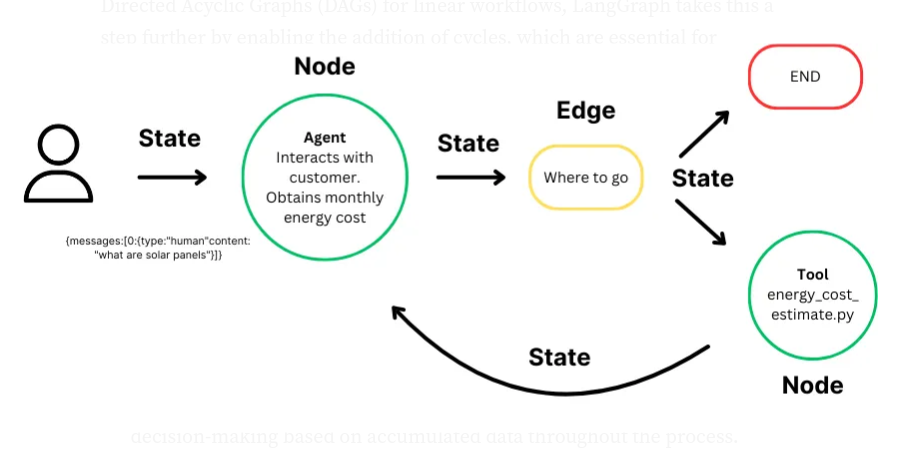

In [ ]:
from  langchain_core.output_parsers import StrOutputParser

In [ ]:

# generate_chain = sentiment_prompt | llm.with_structured_output(SentimentAnalyser)
generate_chain = sentiment_prompt | llm | StrOutputParser()

reflect_chain = reflection_prompt | llm.with_structured_output(Judge)

# Graph definition
class GraphState(TypedDict):
    iteration: int
    sentiment: str
    agreement: str
    messages: List
    stock_name: str
    news_text: str



In [ ]:
graph = StateGraph(GraphState)

def generate_sentiment(state):
    state['iteration'] += 1
    response = generate_chain.invoke(
        {"messages": state["messages"], "stock": state['stock_name'],
         "text": state['news_text']})
    # state['sentiment'] =
    print(response)
    state['messages'].append(('ai', response)) #AIMessage, HumanMessage(content='njkljf')
    # print('new message is:', ('ai', response))
    print('state message', state['messages'])
    return state

def reflect_sentiment(state):
    reflection_input = {
        "messages": state["messages"],
        "stock": state['stock_name'],
        "text": state['news_text'],
    }
    response = reflect_chain.invoke(reflection_input)
    state['agreement'] = response.agreement
    state['messages'].append(
        HumanMessage(content=f"""The sentiment analysis for {state['stock_name']}
                     resulted in an agreement status of '{response.agreement}'.
                     Here is the reasoning provided: {response.reasoning}"""))
    # state['agreement'] = response.agreement
    return state


def should_continue(state):
    if state['agreement'] == 'yes' or state['iteration'] >= state.get("max_iterations", 5):
        return END
    return "generate_sentiment"

# Add nodes

graph.add_node("generate_sentiment", generate_sentiment)
graph.add_node("reflect_sentiment", reflect_sentiment)

# Define flow
graph.add_edge(START, "generate_sentiment")

graph.add_edge("generate_sentiment", "reflect_sentiment")
graph.add_conditional_edges("reflect_sentiment", should_continue, {
    END: END,
    "generate_sentiment": "generate_sentiment"
})

# Compile graph
app = graph.compile()

# Invocation
initial_state = {
    "messages":[],
    "iteration": 0,
    "max_iterations": 5,
    "stock_name": stock,
    "news_text": text
}



In [ ]:
final_state = app.invoke(initial_state)


Sentiment: Positive

Reasoning: The news reflects a strong commitment to the economic success and values of the Islamic Revolution, emphasizing the efforts of Bank صادرات ایران in supporting the economy and contributing positively to the country's objectives. This sentiment suggests an optimistic outlook for the stock related to صادرات ایران, indicating potential stability or growth in its value.
state message [('ai', "Sentiment: Positive\n\nReasoning: The news reflects a strong commitment to the economic success and values of the Islamic Revolution, emphasizing the efforts of Bank صادرات ایران in supporting the economy and contributing positively to the country's objectives. This sentiment suggests an optimistic outlook for the stock related to صادرات ایران, indicating potential stability or growth in its value.")]
Sentiment: Positive

Reasoning: The news highlights the ongoing efforts of Bank صادرات ایران to support the economy and uphold the values of the Islamic Revolution. This fo

In [ ]:
final_state

{'iteration': 5,
 'agreement': 'agree',
 'messages': [('ai',
   "Sentiment: Positive\n\nReasoning: The news reflects a strong commitment to the economic success and values of the Islamic Revolution, emphasizing the efforts of Bank صادرات ایران in supporting the economy and contributing positively to the country's objectives. This sentiment suggests an optimistic outlook for the stock related to صادرات ایران, indicating potential stability or growth in its value."),
  HumanMessage(content="The sentiment analysis for صادرات ایران\n                     resulted in an agreement status of 'agree'.\n                     Here is the reasoning provided: default=Ellipsis description='Return the reasoning behind the agreement or disagreement' extra={}", additional_kwargs={}, response_metadata={}),
  ('ai',
   'Sentiment: Positive\n\nReasoning: The news highlights the ongoing efforts of Bank صادرات ایران to support the economy and uphold the values of the Islamic Revolution. This focus on economi